# Evaluation results analysis

Reads the files `scripts/eval_ragas.py` writes to `eval_results/` and breaks a run down beyond the printed summary:

- **Run overview**: pass rates for the deterministic checks (route, source, currency, contact), mean RAGAS scores, and any check failures
- **Score distributions**: how each metric's scores spread across questions, not just the mean
- **Every scored question**: a heatmap of all five metrics per question, weakest first
- **By category and question kind**: mean scores per corpus folder and golden-set kind, plus expected against actual route
- **Reading the weakest answers**: the lowest-scoring rows with their question, reference, answer and retrieved contexts
- **Rate-limit retries**: how many rows the Cohere reranker's rate limit slowed down
- **Run history**: mean scores for every run in `eval_results/`, charted once there are two full runs
- **Changes against the comparison run**: per-question score changes and check results that flipped

The RAGAS metrics, each scored 0 to 1 by an LLM judge:

- **faithfulness** (`faith`): share of the answer's claims supported by the retrieved contexts
- **answer_relevancy** (`relev`): how directly the answer addresses the question, judged by generating questions back from the answer and comparing them with the original
- **context_precision** (`c_pre`): whether the contexts that are relevant to the reference answer are ranked above the ones that aren't
- **context_recall** (`c_rec`): share of the reference answer's claims supported by the retrieved contexts
- **factual_correctness** (`fact`): share of the reference answer's claims that the answer states

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

# Kept in step with scripts/eval_ragas.py.
METRICS = ["faithfulness", "answer_relevancy", "context_precision",
           "context_recall", "factual_correctness"]
CHECKS = ["route", "source", "currency", "contact"]
SHORT = {"faithfulness": "faith", "answer_relevancy": "relev", "context_precision": "c_pre",
         "context_recall": "c_rec", "factual_correctness": "fact"}

## Configuration

Leave everything as `None` to analyse the latest local run against the one before it. The same values can be set as environment variables.

In [2]:
# None: the repository this notebook is in. Otherwise a directory laid out like it.
EVAL_ROOT = os.environ.get("EVAL_ROOT")

# A run is named by its results file, e.g. "20260913-003150". None: the latest run.
RUN = os.environ.get("EVAL_RUN")

# The run to compare against. None: the run before RUN, if there is one.
COMPARE_TO = os.environ.get("EVAL_COMPARE_TO")

In [3]:
def resolve_root(root):
    """The directory holding eval_results/, seed/ and data/."""
    if root is not None:
        return Path(root).resolve()
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "eval_results").is_dir():
            return p
    raise FileNotFoundError("no eval_results/ above the notebook; set EVAL_ROOT")


ROOT = resolve_root(EVAL_ROOT)
RESULTS = ROOT / "eval_results"
runs = sorted(p.stem for p in RESULTS.glob("*.jsonl"))
if not runs:
    raise FileNotFoundError(f"no results files in {RESULTS}")

RUN = RUN or runs[-1]
if COMPARE_TO is None and runs.index(RUN) > 0:
    COMPARE_TO = runs[runs.index(RUN) - 1]

print(f"root:       {ROOT}")
print(f"runs:       {', '.join(runs)}")
print(f"analysing:  {RUN}")
print(f"compare to: {COMPARE_TO or '-'}")

root:       C:\Users\nopro\OneDrive\Desktop\tenant-rag-system
runs:       20260913-003150
analysing:  20260913-003150
compare to: -


In [4]:
def read_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


# A row's category is that of its primary source document. Older results files
# don't store it, so it is derived from the golden set and manifest, as
# eval_ragas.py --summarize does.
documents = json.loads((ROOT / "data" / "manifest.json").read_text(encoding="utf-8"))["documents"]
doc_category = {d["doc_id"]: d["category"] for d in documents}
row_category = {
    g["id"]: doc_category[g["sources"][0]["doc_id"]] if g["sources"] else None
    for g in read_jsonl(ROOT / "seed" / "qna_test.jsonl")
}


def load_run(name):
    """(one row per question, raw rows by id) for a run."""
    raw = {r["id"]: r for r in read_jsonl(RESULTS / f"{name}.jsonl")}
    records = []
    for r in raw.values():
        expect = r["expect"]
        rec = {
            "id": r["id"],
            "kind": r["kind"],
            "category": r.get("category") or row_category.get(r["id"]),
            "as_of": r["as_of"],
            "expect": " | ".join(expect) if isinstance(expect, list) else expect,
            "route_taken": r.get("route"),
            "retries": r.get("retries", 0),
            "error": r.get("error"),
        }
        rec.update({c: r["checks"][c]["ok"] if c in r["checks"] else None for c in CHECKS})
        rec.update({m: (r["metrics"].get(m) or {}).get("value") for m in METRICS})
        records.append(rec)
    df = pd.DataFrame(records).set_index("id")
    df[METRICS] = df[METRICS].astype(float)
    return df, raw


def run_info(name):
    path = RESULTS / f"{name}.summary.json"
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else {}


df, raw = load_run(RUN)
scored = df[df[METRICS].notna().any(axis=1)]
print(f"{len(df)} rows, {len(scored)} scored by RAGAS")

49 rows, 40 scored by RAGAS


## Run overview

**Checks** are deterministic pass/fail: route, primary source retrieved, everything retrieved in force on the question's date, and emergency contacts present. Any failure is a bug.

**Metrics** are RAGAS scores from an LLM judge, from 0 to 1. Only rows with a reference answer and retrieved contexts are scored.

In [5]:
info = run_info(RUN)
settings = {k: info.get(k) for k in ["started", "elapsed_s", "judge_model", "cache", "filters",
                                      "metric_errors", "rate_limit_retries"]}
pd.Series(settings, name=RUN, dtype=object).dropna().to_frame()

,20260913-003150
metric_errors,0
rate_limit_retries,38


In [6]:
def check_table(frame):
    return pd.DataFrame({
        c: {"passed": int(frame[c].dropna().astype(bool).sum()), "total": int(frame[c].notna().sum())}
        for c in CHECKS if frame[c].notna().any()
    }).T


def metric_means(frame):
    rows = frame[frame[METRICS].notna().any(axis=1)]
    return rows[METRICS].mean().rename(index=SHORT)


checks = check_table(df)
checks["rate"] = (checks["passed"] / checks["total"]).map("{:.0%}".format)

means = metric_means(df).to_frame(RUN)
if COMPARE_TO:
    base_df, base_raw = load_run(COMPARE_TO)
    means[COMPARE_TO] = metric_means(base_df)
    means["change"] = means[RUN] - means[COMPARE_TO]

display(checks)
display(means.round(3))

,passed,total,rate
route,49,49,100%
source,40,40,100%
currency,40,40,100%
contact,5,5,100%


,20260913-003150
faith,0.982
relev,0.804
c_pre,0.940
c_rec,0.988
fact,0.975


In [7]:
failures = pd.DataFrame(
    [(rid, name, c["detail"]) for rid, r in raw.items() for name, c in r["checks"].items() if not c["ok"]],
    columns=["id", "check", "detail"],
)
failures if len(failures) else print("No check failures.")

No check failures.


## Score distributions

A mean hides whether a metric is uniformly middling or mostly perfect with a few bad rows. Each dot is one question.

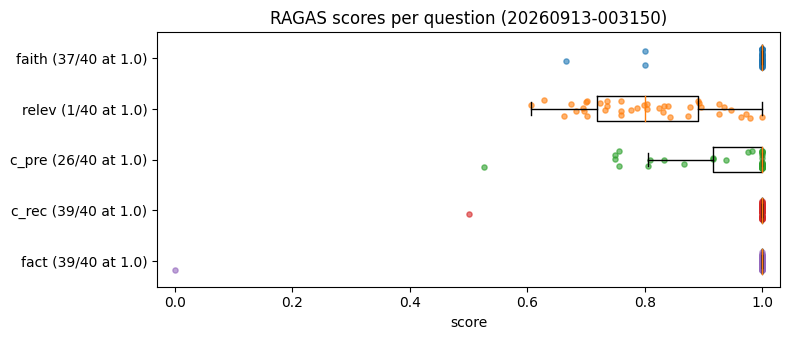

In [8]:
rng = np.random.default_rng(0)
data = [scored[m].dropna() for m in METRICS]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.boxplot(data, vert=False, showfliers=False, widths=0.5)
for i, values in enumerate(data, start=1):
    ax.scatter(values, i + rng.uniform(-0.18, 0.18, len(values)), s=14, alpha=0.6)
# Most scores are exactly 1.0 and the dots stack there, so the label says how many.
ax.set_yticks(range(1, len(METRICS) + 1),
              [f"{SHORT[m]} ({(v >= 0.995).sum()}/{len(v)} at 1.0)" for m, v in zip(METRICS, data)])
ax.set_xlim(-0.03, 1.03)
ax.set_xlabel("score")
ax.set_title(f"RAGAS scores per question ({RUN})")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Every scored question

Sorted with the weakest rows, by mean score, at the top. `answer_relevancy` works by generating questions back from the answer and comparing them with the original question, so it tends to sit lower than the other metrics even for correct answers. Compare a row against the rest of its column rather than against 1.0.

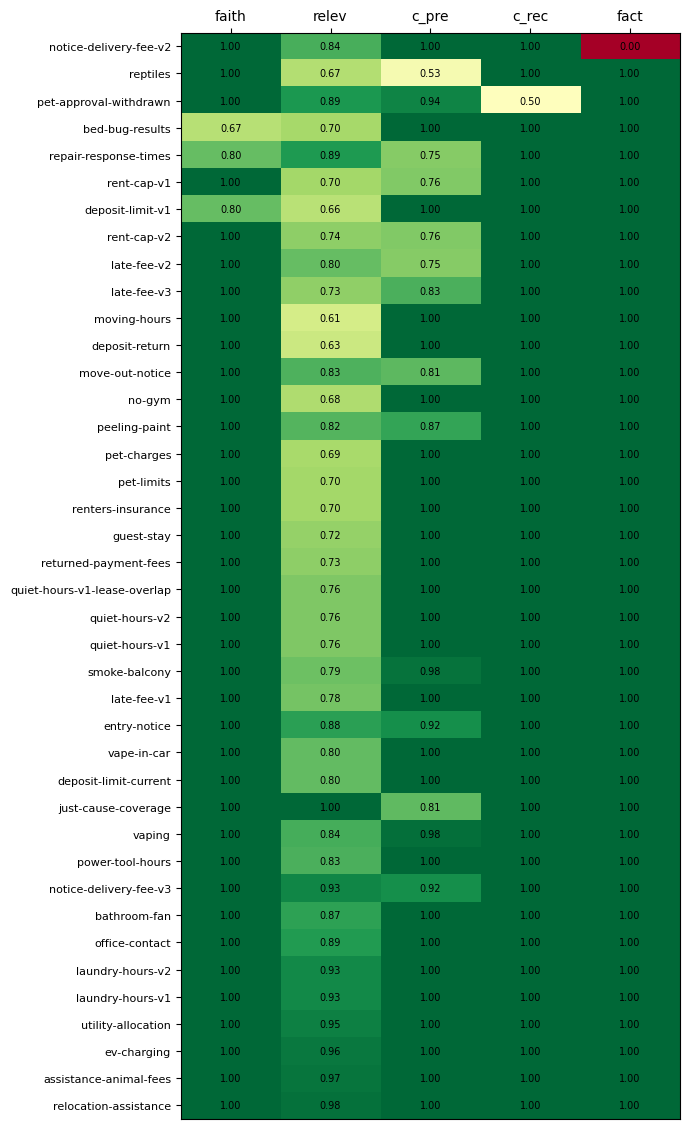

In [9]:
heat = scored[METRICS].assign(_mean=scored[METRICS].mean(axis=1)).sort_values("_mean")[METRICS]

fig, ax = plt.subplots(figsize=(7, 0.26 * len(heat) + 1))
ax.imshow(heat.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(METRICS)), [SHORT[m] for m in METRICS])
ax.xaxis.tick_top()
ax.set_yticks(range(len(heat)), heat.index, fontsize=8)
for (i, j), v in np.ndenumerate(heat.values):
    if not np.isnan(v):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
plt.tight_layout()
plt.show()

## By category and question kind

Category is the corpus folder of the question's primary source. Kind is the golden set's label: `version` rows ask the same question on different dates, `fact` rows have a single answer. Groups with a small `n` move a lot between runs.

In [10]:
def breakdown(column):
    groups = scored.groupby(column)
    return (groups[METRICS].mean().rename(columns=SHORT).round(2)
            .assign(n=groups.size()).sort_values("n", ascending=False))


display(breakdown("category"))
display(breakdown("kind"))

,faith,relev,c_pre,c_rec,fact,n
category,,,,,,
policies,0.98,0.77,0.90,1.0,0.95,19
rules,1.00,0.83,1.00,1.0,1.00,10
addenda,0.93,0.84,0.99,0.9,1.00,5
disclosures,1.00,0.93,0.89,1.0,1.00,3
property,1.00,0.79,1.00,1.0,1.00,2
lease,1.00,0.70,1.00,1.0,1.00,1


,faith,relev,c_pre,c_rec,fact,n
kind,,,,,,
fact,0.98,0.80,0.94,0.98,1.00,22
version,0.99,0.79,0.93,1.00,0.93,14
flagged,1.00,0.99,0.90,1.00,1.00,2
guardrail,1.00,0.79,0.98,1.00,1.00,1
negative,1.00,0.68,1.00,1.00,1.00,1


Expected route against actual route for every row, scored or not. Anything off the diagonal is also a route check failure, unless the row accepts more than one route.

In [11]:
pd.crosstab(df["expect"], df["route_taken"].fillna("error"), margins=True)

route_taken,answer,flagged_document,immediate_danger,maintenance_emergency,no_answer,safety_concern,All
expect,,,,,,,
answer,38,0,0,0,0,0,38
answer | no_answer,0,0,0,0,1,0,1
flagged_document,0,2,0,0,0,0,2
immediate_danger,0,0,1,0,0,0,1
maintenance_emergency,0,0,0,3,0,0,3
no_answer,0,0,0,0,3,0,3
safety_concern,0,0,0,0,0,1,1
All,38,2,1,3,4,1,49


## Reading the weakest answers

The lowest rows below 1.0 for each metric, then the question, reference and answer for the weakest rows overall. A low score is either a pipeline problem, a golden-set problem, or judge noise, and the text is the only way to tell which.

In [12]:
lowest = pd.concat(
    {SHORT[m]: scored[m][scored[m] < 1].nsmallest(3).round(2).reset_index().rename(columns={m: "score"})
     for m in METRICS}
)
lowest

id  score
faith 0         bed-bug-results   0.67
      1        deposit-limit-v1   0.80
      2   repair-response-times   0.80
relev 0            moving-hours   0.61
      1          deposit-return   0.63
      2        deposit-limit-v1   0.66
c_pre 0                reptiles   0.53
      1             late-fee-v2   0.75
      2   repair-response-times   0.75
c_rec 0  pet-approval-withdrawn   0.50
fact  0  notice-delivery-fee-v2   0.00

In [13]:
def show(row_id, context_chars=300):
    r = raw[row_id]
    print(f"== {row_id}  ({r['kind']}, as of {r['as_of']}, route {r.get('route')})")
    print("scores:  " + "  ".join(
        f"{SHORT[m]} {df.at[row_id, m]:.2f}" for m in METRICS if not np.isnan(df.at[row_id, m])))
    print(f"\nQUESTION   {r['question']}")
    print(f"REFERENCE  {r['reference']}")
    print(f"ANSWER     {r.get('answer', '').strip()}")
    print("\nCONTEXTS")
    for i, c in enumerate(r.get("contexts", []), start=1):
        print(f"  [{i}] {' '.join(c.split())[:context_chars]}")
    print()


for row_id in heat.index[:3]:
    show(row_id)

== notice-delivery-fee-v2  (version, as of 2024-10-01, route answer)
scores:  faith 1.00  relev 0.84  c_pre 1.00  c_rec 1.00  fact 0.00

QUESTION   Is there a fee for delivering a legal notice to the office?
REFERENCE  Yes. There is a $10 fee for delivering a legal notice to the office.
ANSWER     Yes, there was a fee for delivering a legal notice to the office of $10 according to the Payment & Billing Policy — Maple Court (v2, effective 1 July 2024) §7 Administrative fees. However, these fees were discontinued on 1 April 2025 and are prohibited under current policy. 

Source: Payment & Billing Policy — Maple Court (v2, effective 1 July 2024) §7 Administrative fees

CONTEXTS
  [1] Source: Payment & Billing Policy — Maple Court (v2, effective 1 July 2024) §7 Administrative fees 7. Administrative fees • Delivery of a legal notice to the office: $10 • Security deposit paid by check: $5 handling These two fees were discontinued on 1 April 2025 and are prohibited under current pol
  [2] Sou

To read any other row, call `show("<id>")`, for example `show("late-fee-v3")`.

## Rate-limit retries

On a Cohere trial key the reranker allows about 10 calls a minute, and rate-limited rows are retried with backoff. Many retries mean a slow run, not a wrong answer.

In [14]:
print(f"{int(df['retries'].sum())} retries across {int((df['retries'] > 0).sum())} of {len(df)} rows")
df["retries"].value_counts().sort_index().rename_axis("retries").to_frame("rows")

38 retries across 23 of 49 rows


,rows
retries,
0,26
1,12
2,7
3,4


## Run history

Every run in `eval_results/`. Runs filtered with `--id` or `--kind` cover fewer rows, so their means are not comparable with full runs.

In [15]:
history = []
for name in runs:
    frame, _ = load_run(name)
    info = run_info(name)
    checks_ = check_table(frame)
    history.append({
        "run": name,
        "rows": len(frame),
        "filtered": bool(info.get("filters") and any(info["filters"].values())),
        "checks_passed": f"{checks_['passed'].sum()}/{checks_['total'].sum()}",
        **metric_means(frame).round(3).to_dict(),
    })
history = pd.DataFrame(history).set_index("run")
display(history)

full = history[~history["filtered"]]
if len(full) >= 2:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    for name in SHORT.values():
        ax.plot(range(len(full)), full[name], marker="o", label=name)
    ax.set_xticks(range(len(full)), full.index, rotation=30, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_title("Mean RAGAS scores, full runs")
    ax.legend(loc="lower left", ncol=len(SHORT))
    plt.tight_layout()
    plt.show()
else:
    print("One full run so far; the trend chart appears once there are two.")

,rows,filtered,checks_passed,faith,relev,c_pre,c_rec,fact
run,,,,,,,,
20260913-003150,49,False,134/134,0.982,0.804,0.94,0.988,0.975


One full run so far; the trend chart appears once there are two.


## Changes against the comparison run

Per-question score changes and check results that flipped. Single-row scores vary between identical runs, so a drop is worth reading when it is large or repeats across runs, not on its own.

In [16]:
if not COMPARE_TO:
    print("Nothing to compare against: only one run. Set COMPARE_TO or run the evaluation again.")
else:
    delta = (df[METRICS] - base_df[METRICS]).dropna(how="all").rename(columns=SHORT)
    delta = delta[(delta.abs() > 0.005).any(axis=1)]
    delta["worst"] = delta.min(axis=1)
    print(f"{RUN} minus {COMPARE_TO}: {len(delta)} rows changed, largest drops first")
    display(delta.sort_values("worst").head(15).round(2))

    flipped = [
        (rid, c, base_df.at[rid, c], df.at[rid, c])
        for rid in df.index.intersection(base_df.index) for c in CHECKS
        if pd.notna(df.at[rid, c]) and pd.notna(base_df.at[rid, c])
        and df.at[rid, c] != base_df.at[rid, c]
    ]
    added, removed = df.index.difference(base_df.index), base_df.index.difference(df.index)
    if flipped:
        display(pd.DataFrame(flipped, columns=["id", "check", COMPARE_TO, RUN]))
    else:
        print("No check results changed.")
    if len(added) or len(removed):
        print(f"rows only in {RUN}: {list(added)}")
        print(f"rows only in {COMPARE_TO}: {list(removed)}")

Nothing to compare against: only one run. Set COMPARE_TO or run the evaluation again.
